<a href="https://colab.research.google.com/github/Aryan1mishra/Ola-dataset-insights/blob/main/OLA_dataset_predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ola Bike Ride Demand & Weather Impact Analysis**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df=pd.read_csv("/content/ola data/ola.csv")
df

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213
...,...,...,...,...,...,...,...,...,...
10881,2012-03-29 09:00:00,4,4,28.24,67.88,47.74,48,28,76
10882,2012-03-29 10:00:00,3,4,17.13,22.36,15.27,4,1,5
10883,2012-03-29 11:00:00,3,3,19.83,99.17,30.35,38,10,48
10884,2012-03-29 12:00:00,2,4,15.70,77.30,40.16,36,15,51


# Basic insight

In [ ]:
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213


In [ ]:
df.shape

(10886, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        10886 non-null  float64
 4   humidity    10886 non-null  float64
 5   windspeed   10886 non-null  float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 765.6+ KB


In [ ]:
df.isnull().sum()

,0
datetime,0
season,0
weather,0
temp,0
humidity,0
windspeed,0
casual,0
registered,0
count,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['datetime']=pd.to_datetime(df['datetime'])

In [ ]:
df['hour']=df['datetime'].dt.hour

In [ ]:
df['day_name']=df['datetime'].dt.day_name()

In [ ]:
df['month']=df['datetime'].dt.month

In [ ]:
df['year']=df['datetime'].dt.year

In [ ]:
df.describe()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,hour,month,year
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-08-15 18:30:00,2.493937,2.491916,20.137973,59.946072,24.960981,24.517545,99.551442,124.068988,11.493570,5.636781,2011.195297
min,2011-01-01 00:00:00,1.000000,1.000000,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2011.000000
25%,2011-04-24 09:15:00,1.000000,1.000000,12.630000,40.040000,12.522500,12.000000,50.000000,74.000000,5.000000,2.000000,2011.000000
50%,2011-08-15 18:30:00,2.000000,2.000000,20.190000,59.970000,25.000000,25.000000,100.000000,124.000000,11.000000,5.000000,2011.000000
75%,2011-12-07 03:45:00,3.000000,4.000000,27.707500,79.620000,37.427500,37.000000,149.000000,174.000000,17.000000,9.000000,2011.000000
max,2012-03-29 13:00:00,4.000000,4.000000,35.000000,99.980000,49.990000,49.000000,199.000000,248.000000,23.000000,12.000000,2012.000000
std,NaN,1.120531,1.123139,8.696625,22.987200,14.424684,14.390014,57.541131,59.449265,6.921882,3.599544,0.396447


# Univariate Analysis

## Distribution of total rides

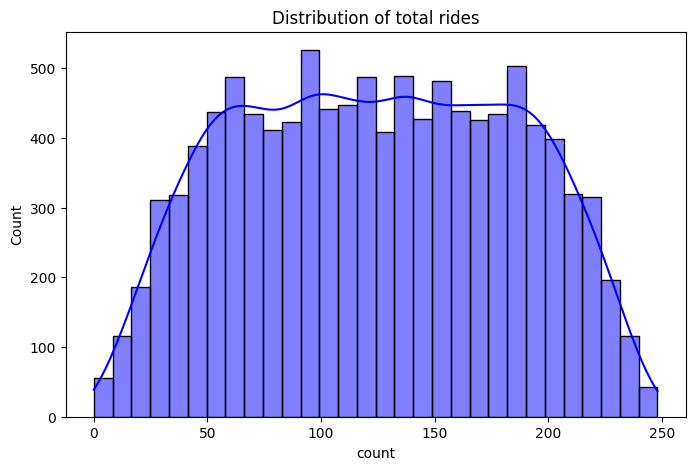

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['count'],bins=30,kde=True,color='blue')
plt.title('Distribution of total rides')
plt.show()


## Temprature distrubution

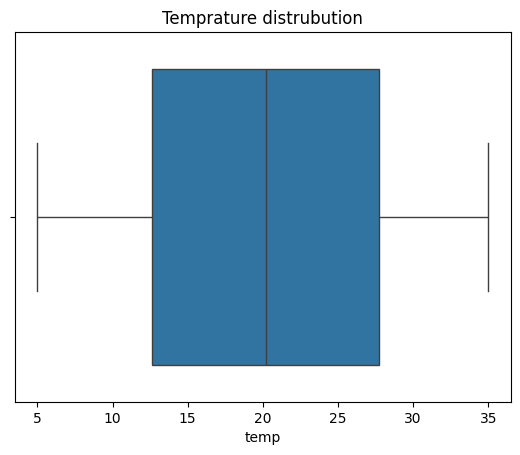

In [ ]:
sns.boxplot(x=df['temp'])
plt.title("Temprature distrubution")
plt.show()

# Bivariate Analysis

## Temprature vs Ride

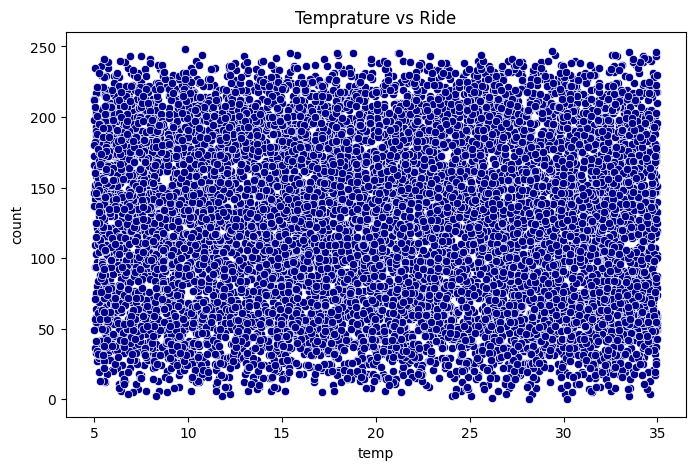

In [ ]:

plt.figure(figsize=(8,5))
sns.scatterplot(x='temp',y='count',data=df,color='darkblue')
plt.title('Temprature vs Ride')
plt.show()

## Humidity vs Ride


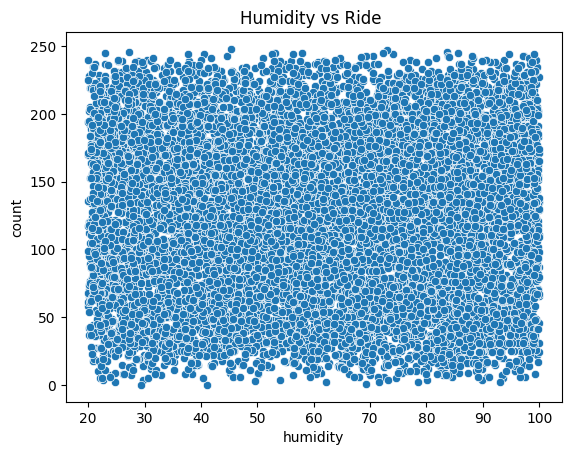

In [ ]:
sns.scatterplot(x='humidity',y='count',data=df)
plt.title("Humidity vs Ride ")
plt.show()

## Wather vs Ride

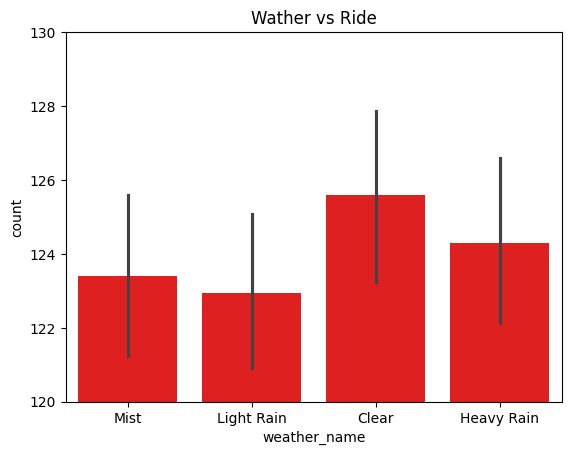

In [ ]:
weather_map={1:'Clear',2:'Mist',3:'Light Rain',4:'Heavy Rain'}
df['weather_name']=df['weather'].map(weather_map)
sns.barplot(x='weather_name', y='count',data=df,color='red')
plt.title("Wather vs Ride")
plt.ylim(120, 130)
plt.show()

## Windspeed vs Ride

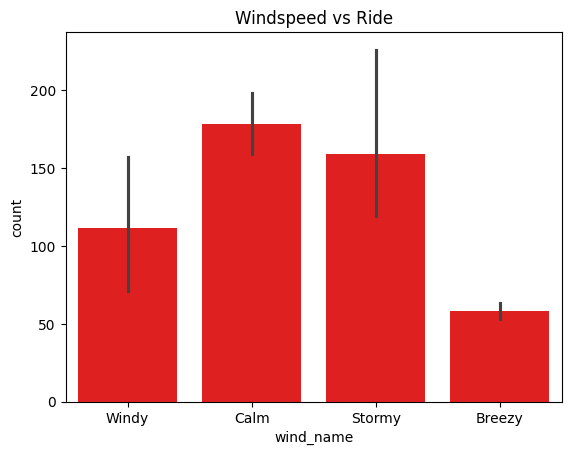

In [ ]:
wind_map={1:'Calm',2:'Breezy',3:'Windy',4:'Stormy'}
df['wind_name']=df['windspeed'].map(wind_map)
sns.barplot(x='wind_name', y='count',data=df,color='red')
plt.title("Windspeed vs Ride")
plt.show()

# Time Series Analysis

## Hourly Ride demand

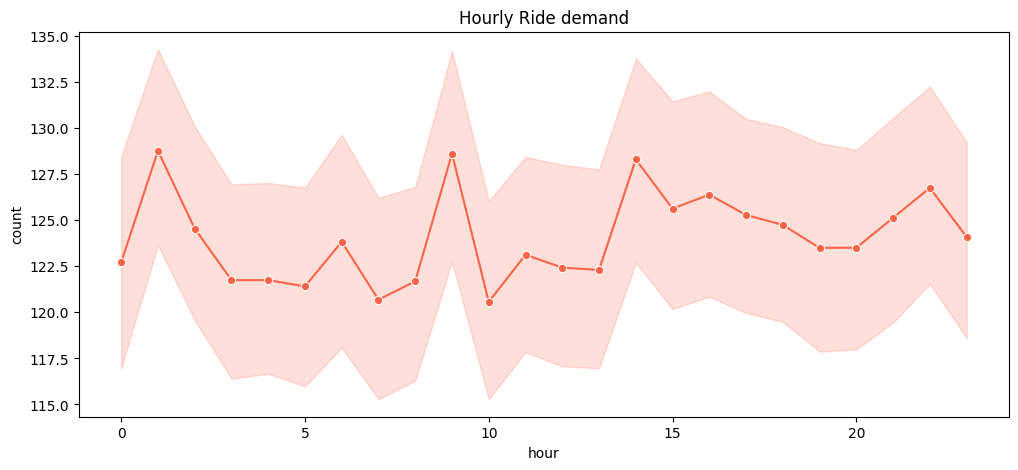

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(x='hour',y='count',data=df,marker='o',color='tomato')
plt.title('Hourly Ride demand')
plt.show()

## Monthly Ride demand

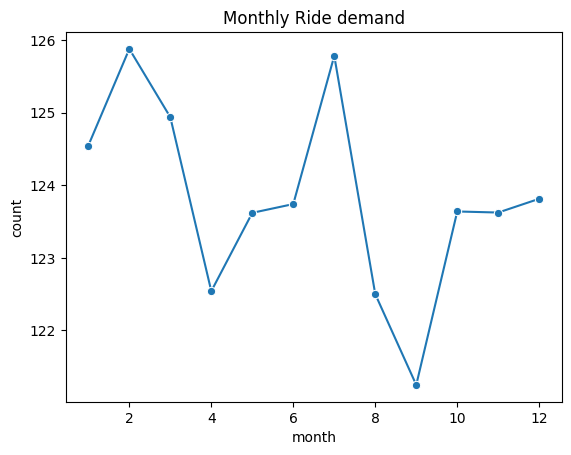

In [ ]:
sns.lineplot(x='month',y='count',data=df,marker='o',errorbar=None)
plt.title('Monthly Ride demand')
plt.show()

# Casual vs Registered Users

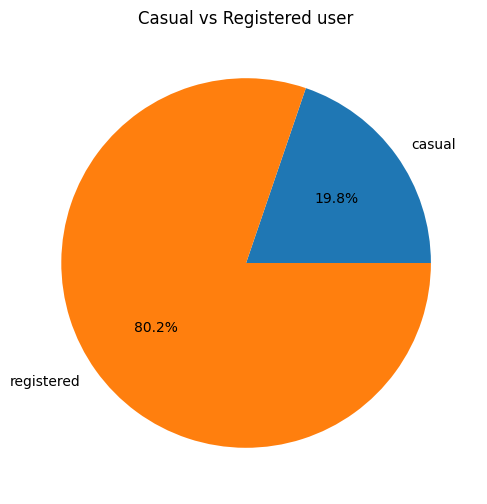

In [ ]:
user_data=df[['casual','registered']].sum()
plt.figure(figsize=(6,6))
plt.pie(user_data,labels=user_data.index,autopct='%1.1f%%')
plt.title('Casual vs Registered user')
plt.show()

# Correlation Analysis

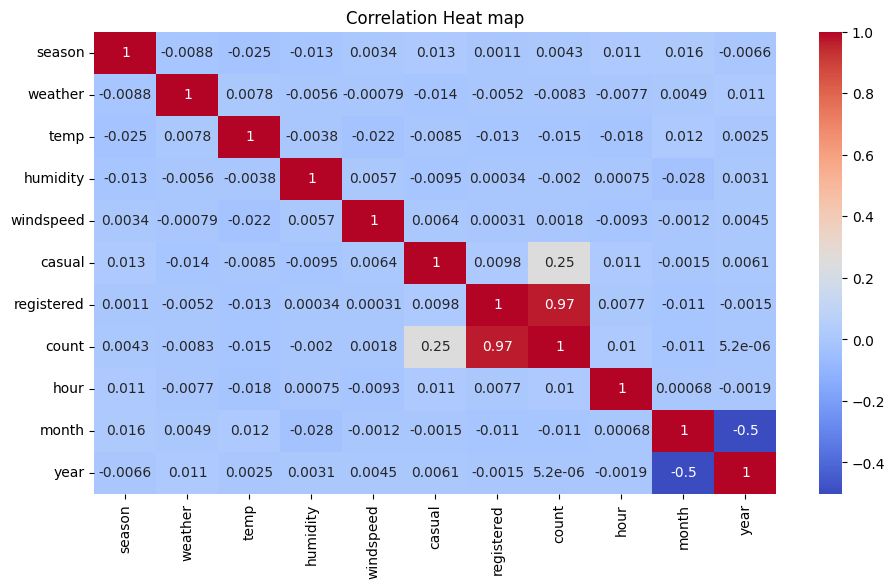

In [ ]:
plt.figure(figsize=(11,6))
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("Correlation Heat map")
plt.show()

# Peak Demand Analysis

In [ ]:
peak_hours=df.groupby('hour')['count'].mean().sort_values(ascending=False)
print(peak_hours)

hour
1     128.781938
9     128.632159
14    128.315673
22    126.766004
16    126.397351
15    125.637969
17    125.295806
21    125.141280
18    124.752759
2     124.555066
23    124.097130
6     123.834802
20    123.512141
19    123.507726
11    123.129956
0     122.713656
12    122.433921
13    122.306167
4     121.753304
3     121.753304
8     121.689427
5     121.411894
7     120.691630
10    120.572687
Name: count, dtype: float64


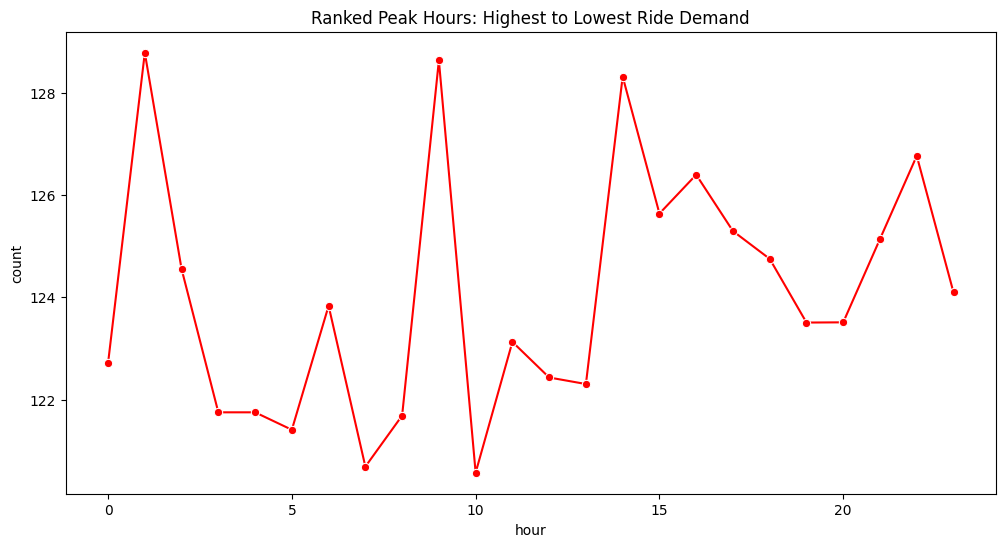

In [ ]:
peak_hour_df= peak_hours.reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='hour', y='count', data=peak_hour_df, sort=True, color='red',marker='o')
plt.title('Ranked Peak Hours: Highest to Lowest Ride Demand')
plt.show()

# Season Analysis

In [ ]:
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_name']=df['season'].map(season_map)

season_data=df.groupby('season_name')['count'].mean().sort_values(ascending=False).reset_index()
print(season_data)

  season_name       count
0        Fall  125.342007
1      Summer  124.227690
2      Winter  123.557721
3      Spring  123.173266


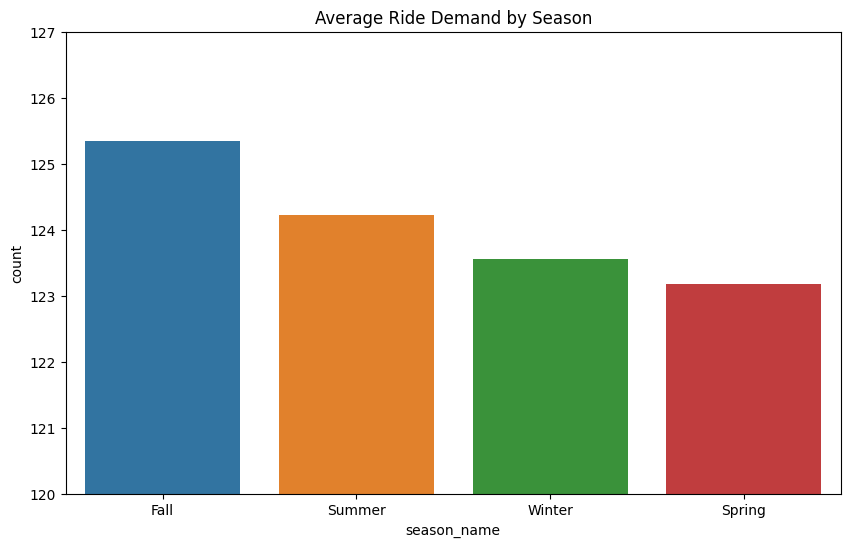

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='season_name', y='count', data=season_data, hue='season_name')
plt.ylim(120, 127)
plt.title('Average Ride Demand by Season')
plt.show()

# Weather Impact Analysis

In [ ]:
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Rain', 4: 'Heavy Rain'}
df['weather_name']=df['weather'].map(weather_map)
weather_data=df.groupby('weather_name')['count'].mean().sort_values(ascending=False).reset_index()
print(weather_data)

  weather_name       count
0        Clear  125.602453
1   Heavy Rain  124.289426
2         Mist  123.395588
3   Light Rain  122.933484


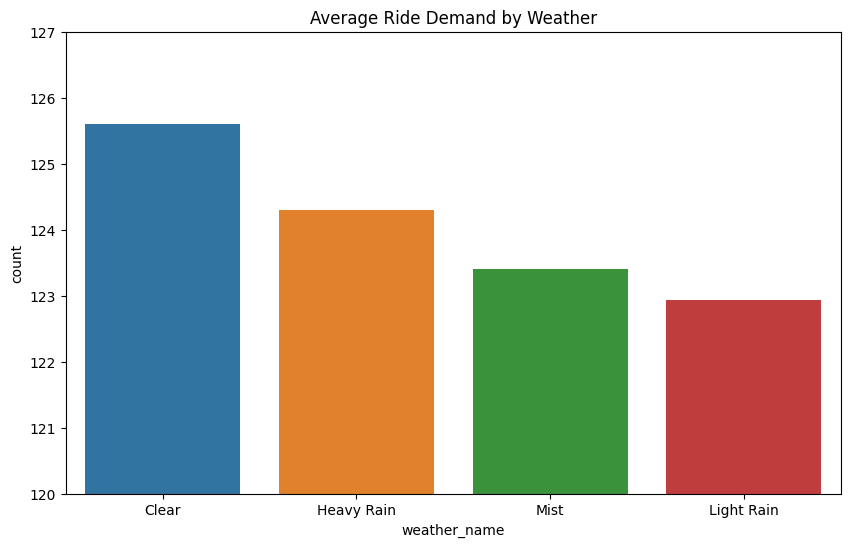

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='weather_name', y='count', data=weather_data, hue='weather_name')
plt.ylim(120, 127)
plt.title('Average Ride Demand by Weather')
plt.show()

# Outlier Detection

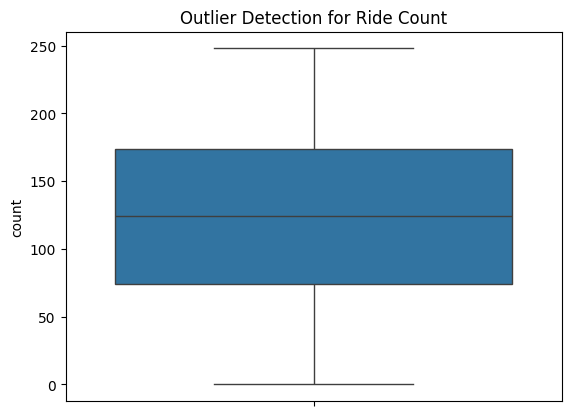

In [ ]:
sns.boxplot(y=df['count'])
plt.title('Outlier Detection for Ride Count')
plt.show()

# Predicting using Ml

Mean Absolute Error : 5.229847431182861
Root Mean Squared Error : 7.376564506493319
R2 Score : 0.9850208163261414


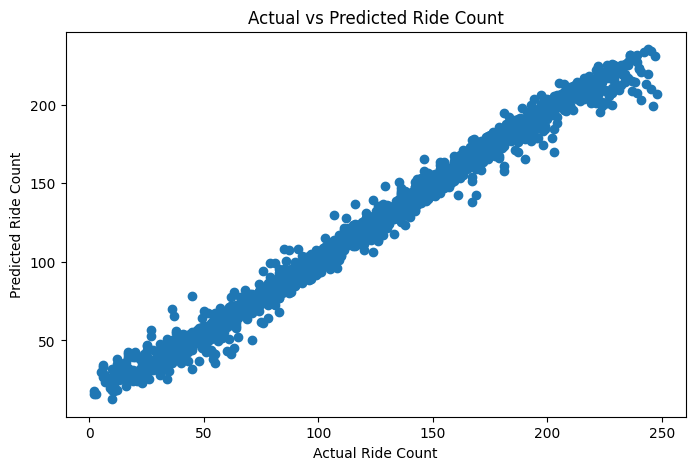

In [ ]:
df = pd.read_csv("/content/ola data/ola.csv")

df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year
df['weekday'] = df['datetime'].dt.weekday

df['is_weekend'] = df['weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

df['lag_1'] = df['count'].shift(1)
df['lag_2'] = df['count'].shift(2)
df['lag_3'] = df['count'].shift(3)

df['rolling_mean_3'] = df['count'].rolling(3).mean()
df['rolling_std_3'] = df['count'].rolling(3).std()

df.dropna(inplace=True)

df = df.drop(columns=['day_name'], errors='ignore')

categorical_cols = [
    'season',
    'weather',
    'weather_name',
    'wind_name',
    'season_name'
]

existing_cols = [
    col for col in categorical_cols
    if col in df.columns
]

if len(existing_cols) > 0:

    df = pd.get_dummies(
        df,
        columns=existing_cols,
        drop_first=True
    )

X = df.drop(columns=[
    'datetime',
    'count',
    'casual',
    'registered'
], errors='ignore')

y = df['count']



split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)


print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ride Count")
plt.ylabel("Predicted Ride Count")

plt.title("Actual vs Predicted Ride Count")

plt.show()